<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B5%D0%B2%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%BC_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


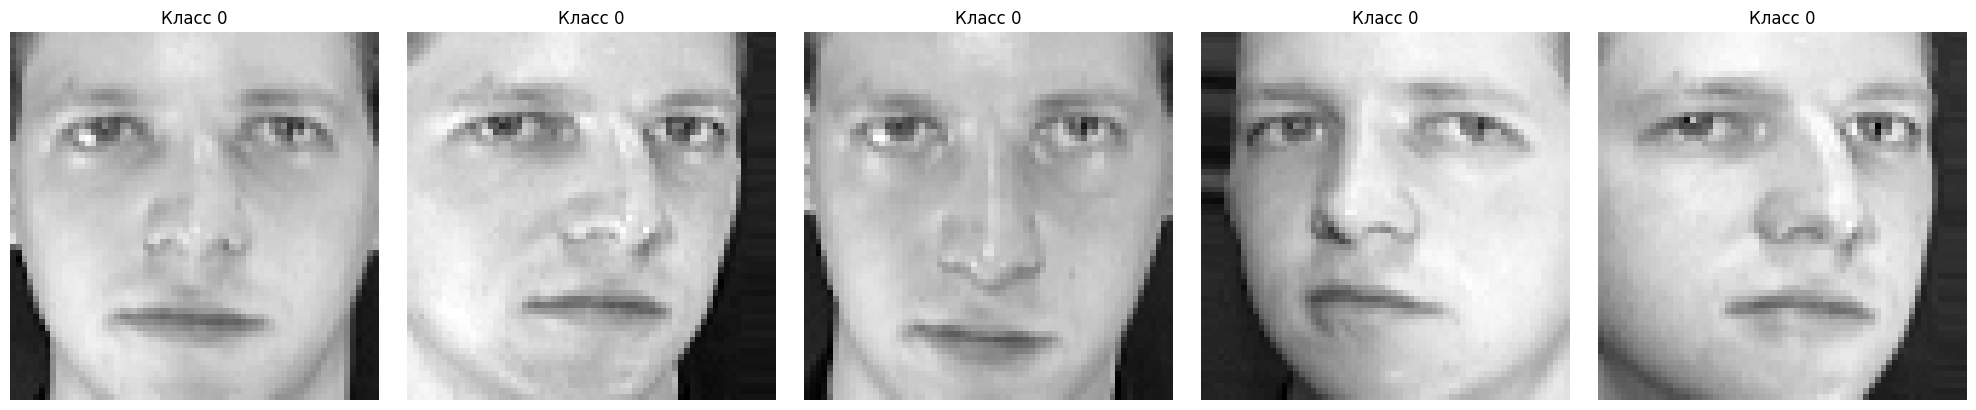

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Обучаем модель: CatBoostClassifier
Accuracy: 0.6000 | Train: 30.494s | Infer: 0.008s
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.33      0.50         3
           3       1.00      0.33      0.50         3
           4       0.50      0.50      0.50         2
           5       0.43      1.00      0.60         3
           6       1.00      0.50      0.67         2
           7       0.50      0.67      0.57         3
           8       0.33      1.00      0.50         2
           9       1.00      0.50      0.67         2
          10       0.75      1.00      0.86         3
          11       1.00      1.00      1.00         3
          12       1.00      0.50      0.67         2
          13       1.00      0.50      0.67         2
          14       1.00      0.67      0.80         3
          15       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.8200 | Train: 16.599s | Infer: 0.012s
              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.50      0.33      0.40         3
           8       0.67      1.00      0.80         2
           9       0.00      0.00      0.00         2
          10       1.00      0.33      0.50         3
          11       1.00      1.00      1.00         3
          12       0.67      1.00      0.80         2
          13       1.00      0.50      0.67         2
          14       1.00      1.00      1.00         3
          15       1.00      0.50      0.67         2
          16       0.50      0.

,Model,Accuracy,train_time,infer_time
1,LGBMClassifier,0.82,16.599438,0.011977
2,XGBClassifier,0.78,30.971065,0.004159
0,CatBoostClassifier,0.60,30.493941,0.007851
3,GradientBoostingClassifier,0.57,160.621742,0.005834


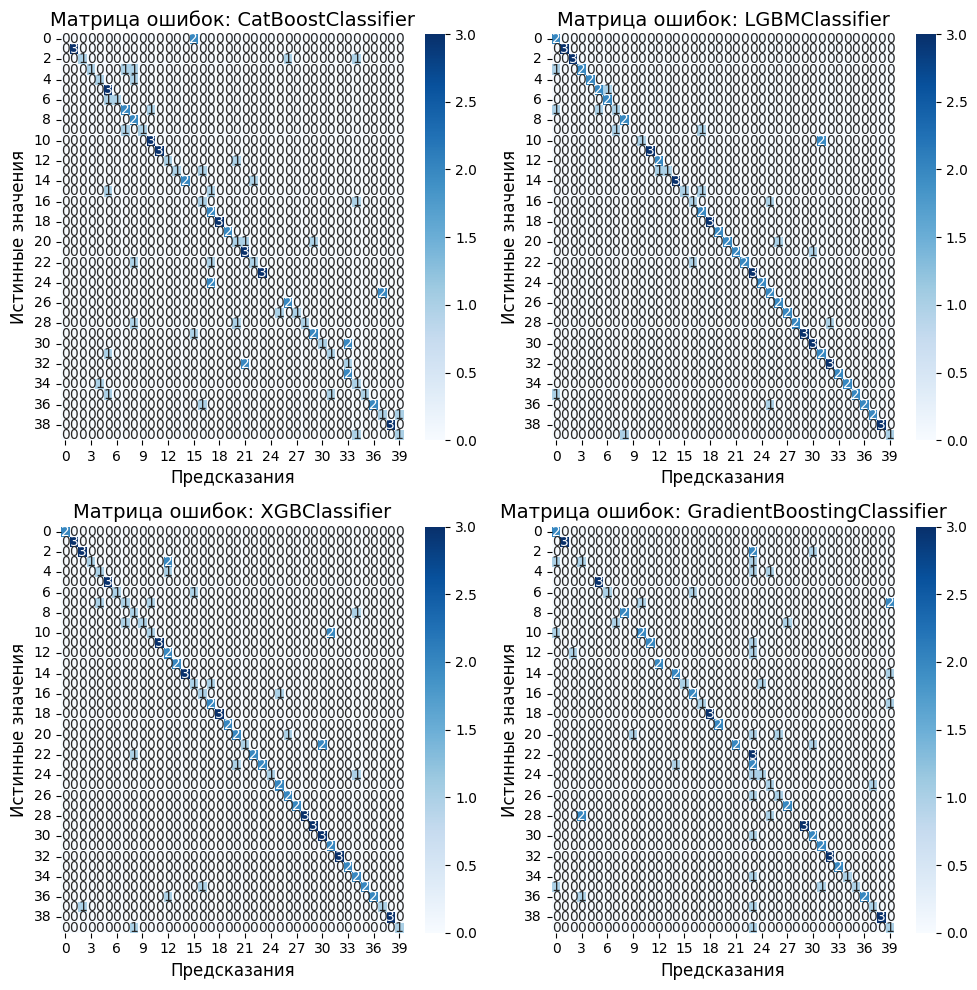

In [ ]:
!pip install catboost lightgbm xgboost -q
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

X = images.reshape(images.shape[0], -1) / 255.0
y = labels

scaler = QuantileTransformer(n_quantiles=100, random_state=0, output_distribution='normal')
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

models = {
    'CatBoostClassifier': CatBoostClassifier(iterations=15, depth=3, learning_rate=0.2, loss_function='MultiClass', verbose=False, random_seed=42),
    'LGBMClassifier': LGBMClassifier(n_estimators=15, max_depth=3, learning_rate=0.2, random_state=42, verbose=-1),
    'XGBClassifier': XGBClassifier(n_estimators=15, max_depth=3, learning_rate=0.2, eval_metric='mlogloss', random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=15, max_depth=2, learning_rate=0.2, random_state=42)
}

results = []
cm_dict = {}

for name, model in models.items():
    print(f"Обучаем модель: {name}")

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - t1

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f} | Train: {train_time:.3f}s | Infer: {infer_time:.3f}s")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm_dict[name] = confusion_matrix(y_test, y_pred)
    results.append([name, acc, train_time, infer_time])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'train_time', 'infer_time'])
display(results_df.sort_values('Accuracy', ascending=False))

num_models = len(cm_dict)
cols = 2
rows = (num_models + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for idx, (model_name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Матрица ошибок: {model_name}', fontsize=14)
    axes[idx].set_xlabel('Предсказания', fontsize=12)
    axes[idx].set_ylabel('Истинные значения', fontsize=12)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

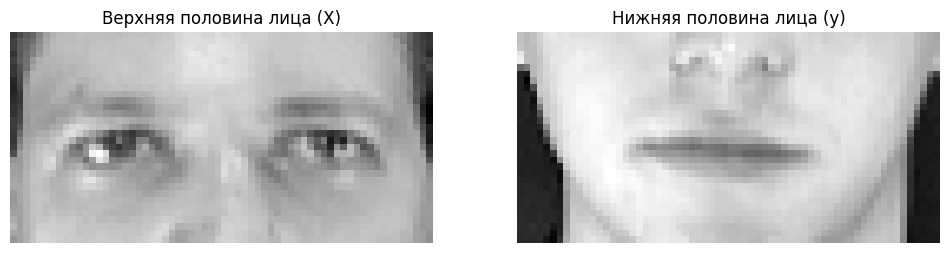

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

Обучаем модель: CatBoostRegressor
R2: 0.2629 | Train: 0.388s | Infer: 0.001s

Обучаем модель: LGBMRegressor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

R2: 0.4488 | Train: 0.273s | Infer: 0.027s

Обучаем модель: XGBRegressor
R2: 0.4452 | Train: 0.832s | Infer: 0.020s

Обучаем модель: GradientBoostingRegressor
R2: 0.4029 | Train: 1.526s | Infer: 0.008s



,Model,R2,train_time,infer_time
1,LGBMRegressor,0.448793,0.272827,0.027319
2,XGBRegressor,0.445236,0.831977,0.019574
3,GradientBoostingRegressor,0.402884,1.525761,0.008199
0,CatBoostRegressor,0.262851,0.387779,0.000761


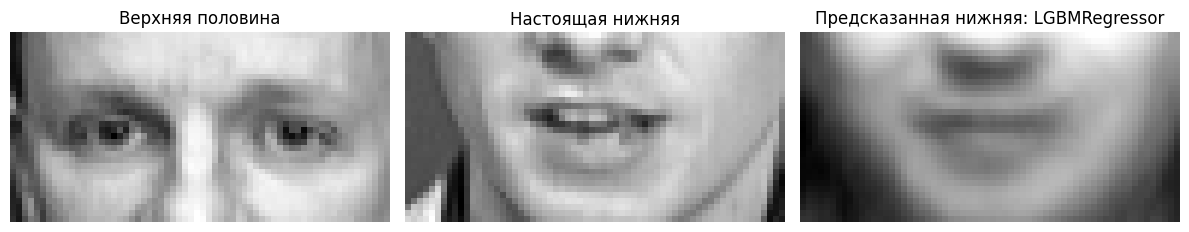

In [ ]:
!pip install catboost lightgbm xgboost -q
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

X = upper_half.reshape(n_samples, -1) / 255.0
y = lower_half.reshape(n_samples, -1) / 255.0

scaler = QuantileTransformer(n_quantiles=100, random_state=0, output_distribution='normal')
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

_, X_test_orig, _, _ = train_test_split(X, y, test_size=0.25, random_state=42)

pca_X = PCA(n_components=40, random_state=42)
pca_y = PCA(n_components=20, random_state=42)

X_train_pca = pca_X.fit_transform(X_train)
X_test_pca = pca_X.transform(X_test)
y_train_pca = pca_y.fit_transform(y_train)

models = {
    'CatBoostRegressor': CatBoostRegressor(
        iterations=15, depth=3, learning_rate=0.2,
        loss_function='MultiRMSE', verbose=False, random_seed=42
    ),
    'LGBMRegressor': MultiOutputRegressor(
        LGBMRegressor(n_estimators=15, max_depth=3, learning_rate=0.2, random_state=42, verbose=-1)
    ),
    'XGBRegressor': MultiOutputRegressor(
        XGBRegressor(n_estimators=15, max_depth=3, learning_rate=0.2, objective='reg:squarederror', random_state=42)
    ),
    'GradientBoostingRegressor': MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=15, max_depth=2, learning_rate=0.2, random_state=42)
    )
}

results = []
predictions = {}

for name, model in models.items():
    print(f"Обучаем модель: {name}")

    t0 = time.time()
    model.fit(X_train_pca, y_train_pca)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred_pca = model.predict(X_test_pca)
    infer_time = time.time() - t1

    y_pred = np.clip(pca_y.inverse_transform(y_pred_pca), 0, 1)

    r2 = r2_score(y_test, y_pred)

    results.append([name, r2, train_time, infer_time])
    predictions[name] = y_pred

    print(f"R2: {r2:.4f} | Train: {train_time:.3f}s | Infer: {infer_time:.3f}s\n")

results_df = pd.DataFrame(results, columns=['Model', 'R2', 'train_time', 'infer_time'])
display(results_df.sort_values('R2', ascending=False))

best_model = results_df.sort_values('R2', ascending=False).iloc[0]['Model']
sample = 0

predicted_lower = predictions[best_model][sample].reshape(32, 64)
true_lower = y_test[sample].reshape(32, 64)
upper = X_test_orig[sample].reshape(32, 64)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(upper, cmap='gray')
axes[0].set_title('Верхняя половина')
axes[0].axis('off')

axes[1].imshow(true_lower, cmap='gray')
axes[1].set_title('Настоящая нижняя')
axes[1].axis('off')

axes[2].imshow(predicted_lower, cmap='gray')
axes[2].set_title(f'Предсказанная нижняя: {best_model}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

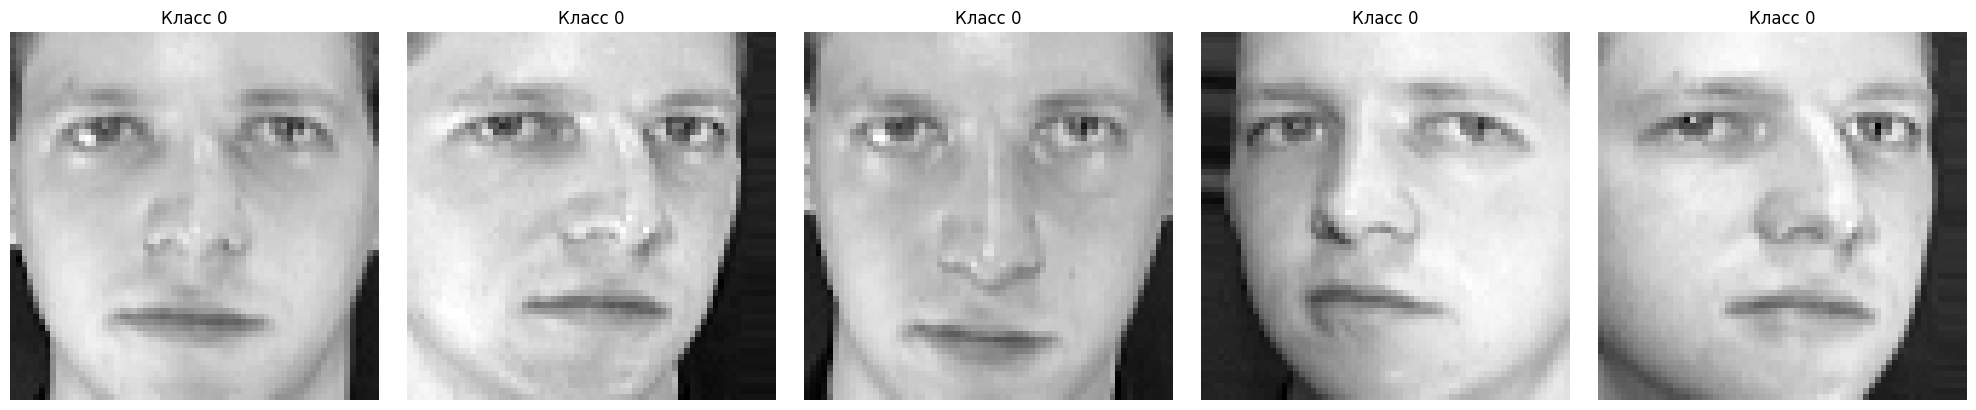

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Обучаем модель: LogisticRegression
Accuracy: 0.9800 | Train: 1.895s | Infer: 0.004s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00        

,Model,Accuracy,train_time,infer_time
0,LogisticRegression,0.98,1.895292,0.004439
4,VotingClassifier,0.96,4.261213,0.110135
3,GaussianNB,0.93,0.011547,0.067851
2,KNeighborsClassifier,0.87,0.001328,0.074708
1,DecisionTreeClassifier,0.63,3.084362,0.000726


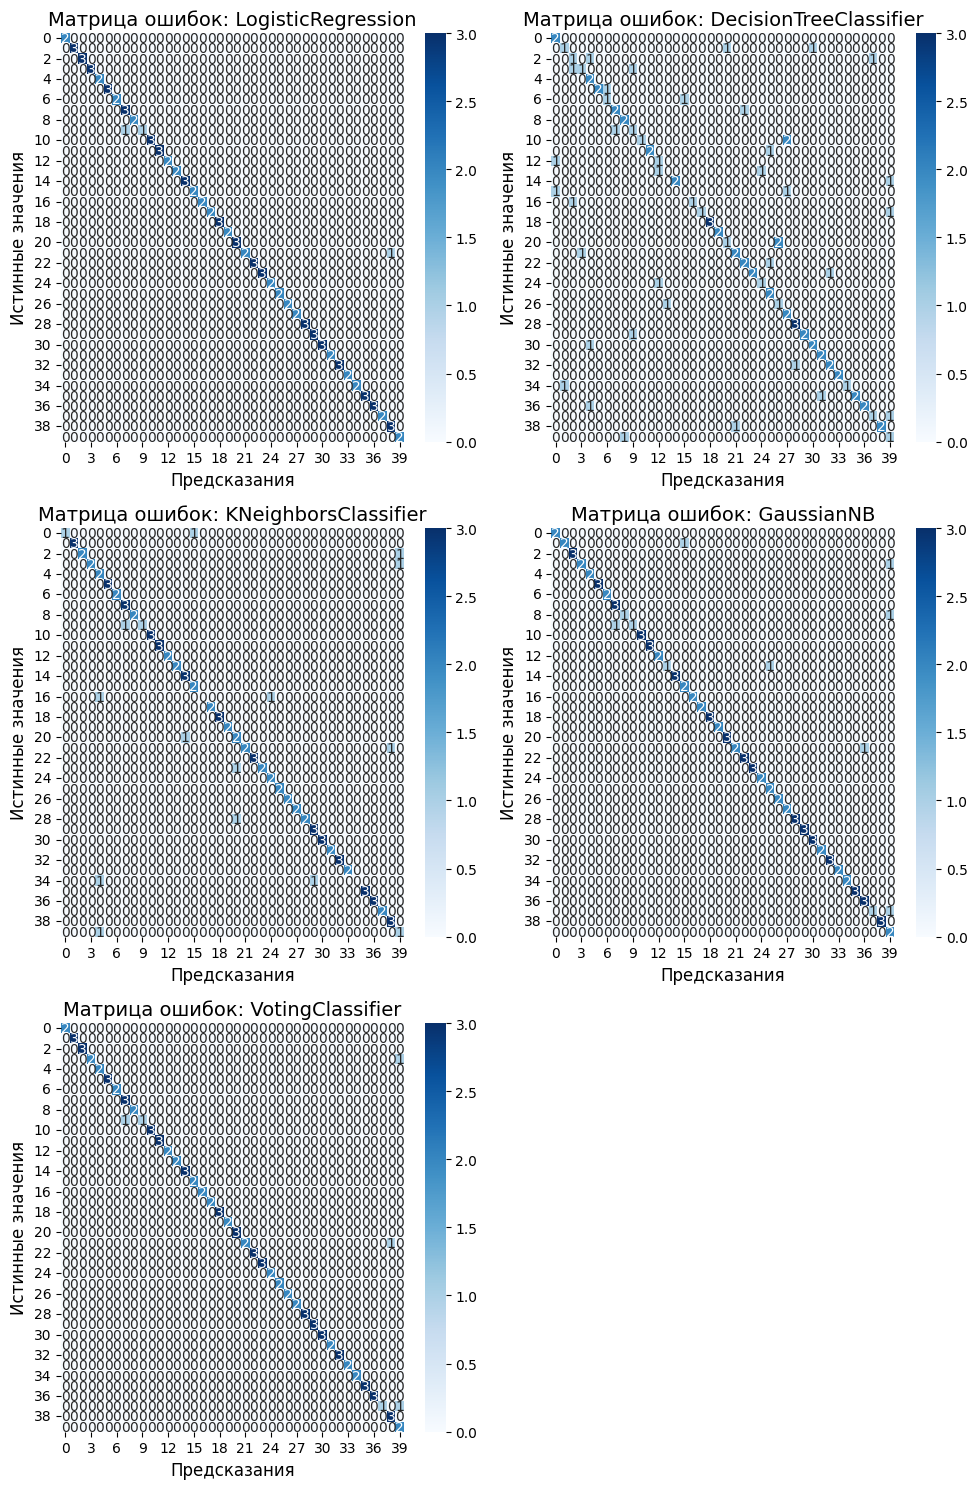

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

X = images.reshape(images.shape[0], -1)
y = labels

scaler = QuantileTransformer(n_quantiles=100, random_state=0, output_distribution='normal')
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'GaussianNB': GaussianNB()
}

voting_clf = VotingClassifier(
    estimators=list(base_models.items()),
    voting='soft'
)
models = {**base_models, 'VotingClassifier': voting_clf}

results = []
cm_dict = {}

for name, model in models.items():
    print(f"Обучаем модель: {name}")

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - t1

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f} | Train: {train_time:.3f}s | Infer: {infer_time:.3f}s")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm_dict[name] = confusion_matrix(y_test, y_pred)
    results.append([name, acc, train_time, infer_time])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'train_time', 'infer_time'])
display(results_df.sort_values('Accuracy', ascending=False))

num_models = len(cm_dict)
cols = 2
rows = (num_models + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for idx, (model_name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Матрица ошибок: {model_name}', fontsize=14)
    axes[idx].set_xlabel('Предсказания', fontsize=12)
    axes[idx].set_ylabel('Истинные значения', fontsize=12)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

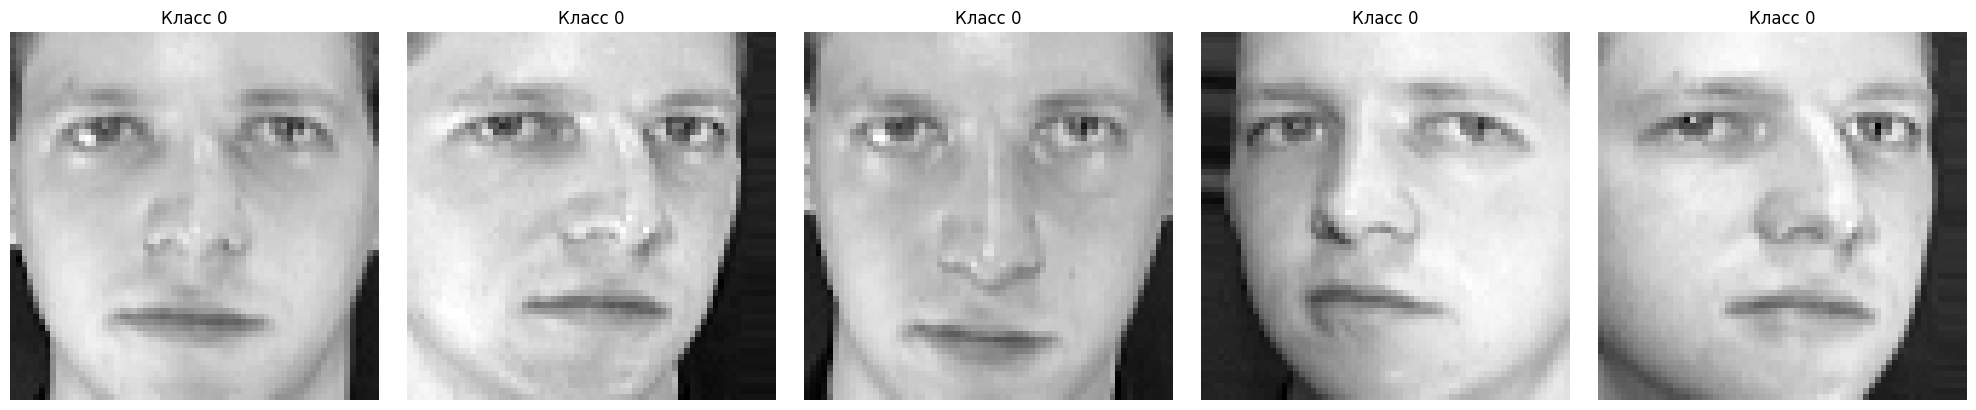

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

=== StackingClassifier ===
Accuracy : 0.9700 | Precision: 0.9783 | Recall: 0.9700 | F1: 0.9681
Train time: 22.0468 s | Infer time: 0.1177 s

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00     

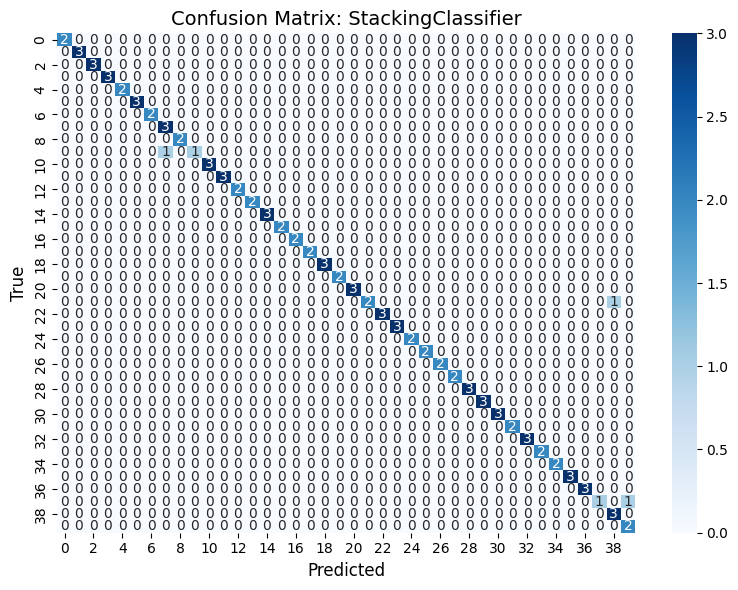

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier

X = images.reshape(images.shape[0], -1) / 255.0
y = labels

scaler = QuantileTransformer(n_quantiles=100, random_state=0, output_distribution='normal')
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ('nb', GaussianNB())
]

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

t0 = time.time()
stacking_clf.fit(X_train, y_train)
train_time = time.time() - t0

t1 = time.time()
y_pred = stacking_clf.predict(X_test)
infer_time = time.time() - t1

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"=== StackingClassifier ===")
print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print(f"Train time: {train_time:.4f} s | Infer time: {infer_time:.4f} s\n")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix: StackingClassifier', fontsize=14)
plt.tight_layout()
plt.show()